In [ ]:
!pip install kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
100% 163M/163M [00:01<00:00, 114MB/s]



In [ ]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
!ls


data  face-mask-dataset.zip  sample_data


**Importing the Dependencies**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1314.jpg', 'with_mask_1848.jpg', 'with_mask_1728.jpg', 'with_mask_2291.jpg', 'with_mask_3081.jpg']
['with_mask_1285.jpg', 'with_mask_191.jpg', 'with_mask_2333.jpg', 'with_mask_1046.jpg', 'with_mask_300.jpg']


In [ ]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1514.jpg', 'without_mask_2597.jpg', 'without_mask_1120.jpg', 'without_mask_2368.jpg', 'without_mask_1579.jpg']
['without_mask_1873.jpg', 'without_mask_1664.jpg', 'without_mask_1624.jpg', 'without_mask_3633.jpg', 'without_mask_1990.jpg']


In [ ]:
print('Number of with mask images', len(with_mask_files))
print('Number of without mask images', len(without_mask_files))

Number of with mask images 3725
Number of without mask images 3828


**Creating images of two class of images**

with mask --> 1

without mask --> 0

In [ ]:
#create the labels
with_mask_labels = [1]*3725
without_mask_labels = [0]*3828

In [ ]:
print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [ ]:
print(len(without_mask_labels))
print(len(with_mask_labels))

3828
3725


In [ ]:
lables = with_mask_labels + without_mask_labels
print(len(lables))
print(lables[0:5])
print(lables[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


**Display Images**

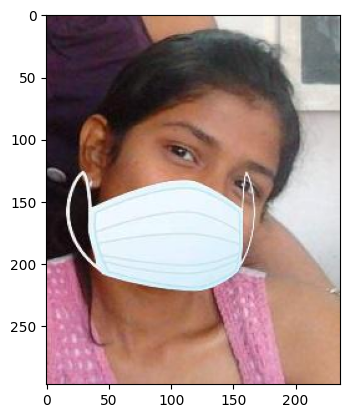

In [ ]:
img = mpimg.imread('/content/data/with_mask/with_mask_1657.jpg')
plt.imshow(img)
plt.show()

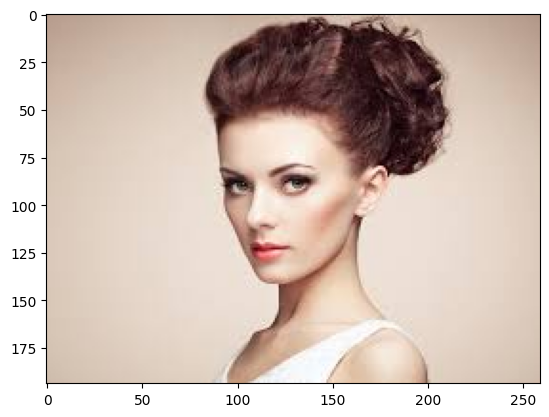

In [ ]:
img = mpimg.imread('/content/data/without_mask/without_mask_3070.jpg')
plt.imshow(img)
plt.show()

**Image Preoccessing**

1. Resize Images

2. Convert Images to Numpy array

In [ ]:
with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)




without_mask_path = '/content/data/without_mask/'

for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
type(data)

list

In [ ]:
len(data)

7553

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[254, 255, 251],
        [253, 255, 253],
        [255, 255, 255],
        ...,
        [235, 218, 194],
        [248, 231, 213],
        [247, 229, 215]],

       [[252, 255, 255],
        [253, 255, 254],
        [255, 255, 255],
        ...,
        [239, 222, 201],
        [246, 229, 213],
        [242, 225, 210]],

       [[251, 255, 255],
        [253, 255, 255],
        [255, 255, 255],
        ...,
        [245, 227, 211],
        [242, 224, 209],
        [224, 206, 191]]], dtype=uint8)
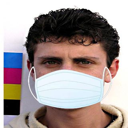

In [ ]:
data[0]

In [ ]:
type(data[0])

numpy.ndarray

In [ ]:
data[0].shape

(128, 128, 3)

In [ ]:
# converting image list and label list to numpy array
X = np.array(data)
Y = np.array(lables)

In [ ]:
type(X)

numpy.ndarray

In [ ]:
type(Y)

numpy.ndarray

In [ ]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [ ]:
print(Y)

[1 1 1 ... 0 0 0]


**Train Test Data**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


Scaling the data it means divided it yo 255. Making every number from 1 to 0

In [ ]:
# scaling the data (Normalization)

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 26,  26,  26],
        [ 44,  44,  46],
        [ 42,  41,  45]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 26,  26,  26],
        [ 33,  33,  35],
        [ 31,  30,  34]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 11,  11,  12],
        [  5,   5,   8],
        [  7,   7,  11]]], dtype=uint8)
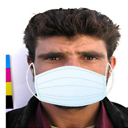

In [ ]:
X_train[0]

In [ ]:
X_train_scaled[0]

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       ...,

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1

##**Building Convolutional Neural Network**

In [ ]:
import tensorflow as tf
from tensorflow import keras

Setting up architecture of our Neural Network

In [ ]:
number_of_classes = 2       #with mask, without mask

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape = (128,128,3)))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPool2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))  # 128 is total number of neurons of this layer
model.add(keras.layers.Dropout(0.5))                   # minimizing risk of overfitting

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

#output layert
model.add(keras.layers.Dense(number_of_classes, activation='sigmoid')) #we use sigmoid for binary classification classes






/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])


In [ ]:
#training the Neural network

history = model.fit(X_train_scaled, Y_train, validation_split=0.2, epochs=5)

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - acc: 0.7312 - loss: 0.5811 - val_acc: 0.8652 - val_loss: 0.3300
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - acc: 0.8674 - loss: 0.3317 - val_acc: 0.8999 - val_loss: 0.2579
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.8955 - loss: 0.2571 - val_acc: 0.9098 - val_loss: 0.2133
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9061 - loss: 0.2421 - val_acc: 0.9272 - val_loss: 0.1724
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9234 - loss: 0.1995 - val_acc: 0.9024 - val_loss: 0.2725


**Model Evaluation**

In [ ]:
loss, acc = model.evaluate(X_test_scaled, Y_test)
print('Test accuracy', acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.8948 - loss: 0.3302
Test accuracy 0.8947716951370239


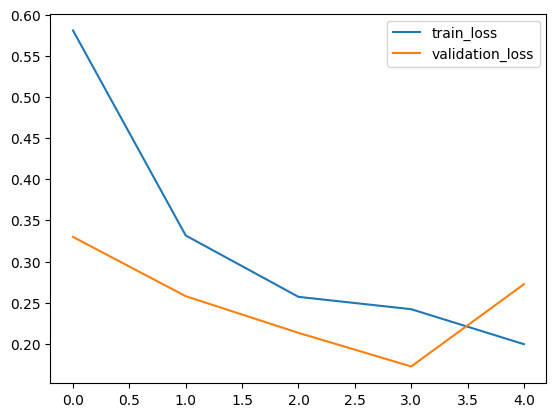

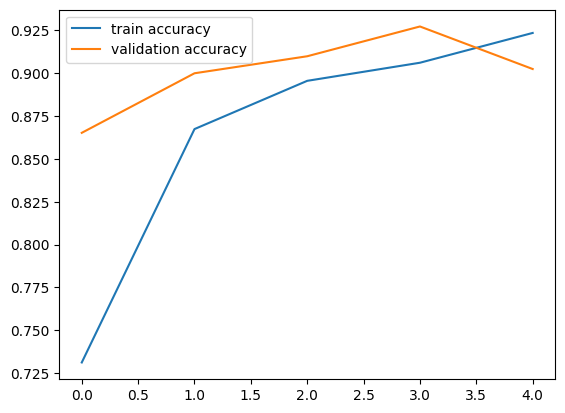

In [ ]:
h = history

# plt the loss value
plt.plot(h.history['loss'], label='train_loss')
plt.plot(h.history['val_loss'], label='validation_loss')
plt.legend()
plt.show()

# plt the accuraccy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()



**Predictive System**

Please put the path of image here to be predicted/content/without_image.jpg


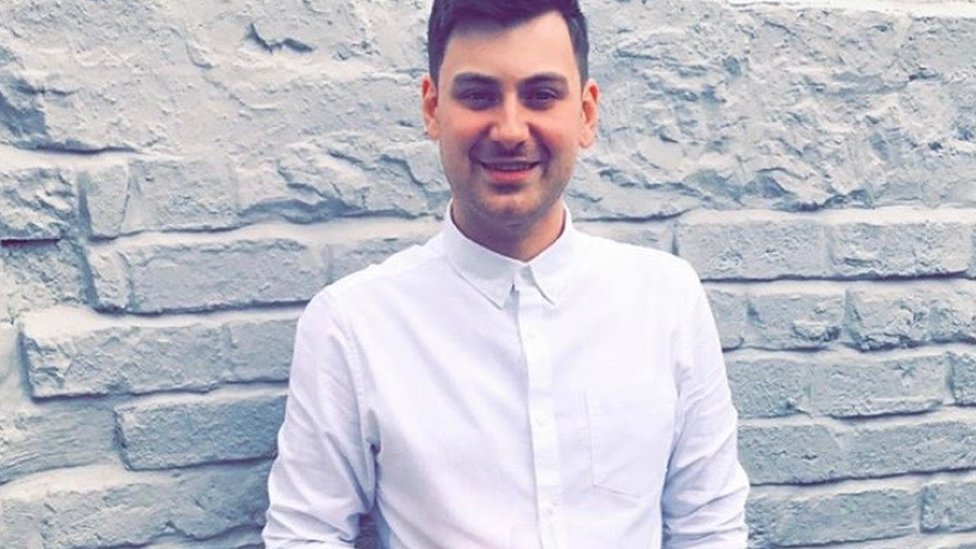

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[0.8369212  0.18815728]]
The person without mask


In [43]:
input_image_path = input('Please put the path of image here to be predicted')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized / 255

input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_prediction_label = np.argmax(input_prediction)

if input_prediction_label == 1:
  print('The person With mask')
else:
  print('The person without mask')